In [ ]:
# install SHAP
!pip install shap -q

Import Libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score)

import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

Load Data

In [ ]:
# Load data
df = pd.read_csv('bridge_master.csv')

# Drop artifact index column if present (from CSV export quirks)
artifact_cols = [c for c in df.columns
                 if 'unnamed' in c.lower() or 'bridge_master' in str(c).lower()]
if artifact_cols:
    df.drop(columns=artifact_cols, inplace=True)
    print(f"Dropped artifact column(s): {artifact_cols}")

print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())

Shape: (9131, 43)
Columns (43):
['ISLAND', 'REGION', 'PROVINCE', 'DEO', 'CONG_DIST', 'ROAD_NAME', 'ROAD_SEC_C', 'SECTION_ID', 'SEC_LENGTH', 'ROUTE_NO', 'Bridge_Loc', 'BRIDGE_ID', 'BR_NAME', 'BR_LENGTH', 'BR_TYPE1', 'BR_TYPE2', 'YR_CONST', 'CONDITION', 'NUM_ABUTT', 'NUM_PIER', 'MaxBRHT', 'MaxPierHT', 'NUM_SPAN', 'BR_WIDTH', 'BR_LIFE', 'LOAD_LIMIT', 'HT_OVER', 'HT_UNDER', 'L_SDWALK', 'R_SDWALK', 'NUM_LANES', 'BNR', 'CROSSING', 'BRGY', 'MUNICIPAL', 'RECOMMEND', 'REMARKS', 'created_us', 'created_da', 'last_edite', 'last_edi_1', 'Actual_Yea', 'geometry']


Inspect Raw Data

In [ ]:
#Inspect Raw Data

print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values (top 15) ===")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f"\n=== CONDITION distribution ===")
print(df['CONDITION'].value_counts())
print(f"\n=== YR_CONST unique values ===")
print(df['YR_CONST'].value_counts(dropna=False))
print(f"\n=== BR_TYPE1 unique values ===")
print(df['BR_TYPE1'].value_counts())
print(f"\n=== BR_TYPE2 unique values ===")
print(df['BR_TYPE2'].value_counts())
print(f"\n=== ROAD_SEC_C unique values ===")
print(df['ROAD_SEC_C'].value_counts())

=== Data Types ===
ISLAND         object
REGION         object
PROVINCE       object
DEO            object
CONG_DIST      object
ROAD_NAME      object
ROAD_SEC_C     object
SECTION_ID     object
SEC_LENGTH      int64
ROUTE_NO       object
Bridge_Loc      int64
BRIDGE_ID      object
BR_NAME        object
BR_LENGTH     float64
BR_TYPE1       object
BR_TYPE2       object
YR_CONST       object
CONDITION      object
NUM_ABUTT       int64
NUM_PIER        int64
MaxBRHT       float64
MaxPierHT     float64
NUM_SPAN        int64
BR_WIDTH      float64
BR_LIFE         int64
LOAD_LIMIT    float64
HT_OVER       float64
HT_UNDER      float64
L_SDWALK      float64
R_SDWALK      float64
NUM_LANES       int64
BNR           float64
CROSSING      float64
BRGY           object
MUNICIPAL      object
RECOMMEND     float64
REMARKS       float64
created_us     object
created_da     object
last_edite     object
last_edi_1     object
Actual_Yea      int64
geometry       object
dtype: object

=== Missing Values (

Create Binary Target

In [ ]:
# Create Binary Target

# Map: Good/Fair → 0 (not at-risk), Poor/Bad → 1 (at-risk)
df['at_risk'] = df['CONDITION'].map({'Good': 0, 'Fair': 0, 'Poor': 1, 'Bad': 1})

# Verify no unmapped values
unmapped = df[df['at_risk'].isna()]['CONDITION'].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped CONDITION values: {unmapped}")
else:
    print("All CONDITION values mapped successfully.")

print(f"\nTarget distribution:")
print(df['at_risk'].value_counts().rename({0: 'Not at-risk (0)', 1: 'At-risk (1)'}))
print(f"\nImbalance ratio: {df['at_risk'].mean():.4f} positive class ({df['at_risk'].sum()} / {len(df)})")

All CONDITION values mapped successfully.

Target distribution:
at_risk
Not at-risk (0)    8401
At-risk (1)         730
Name: count, dtype: int64

Imbalance ratio: 0.0799 positive class (730 / 9131)


Drop Unnecessary Columns

In [ ]:
# Drop Unnecessary Columns
cols_to_drop = []

# --- Admin/metadata (no predictive value) ---
admin_cols = ['created_us', 'created_da', 'last_edite', 'last_edi_1']
cols_to_drop.extend([c for c in admin_cols if c in df.columns])

# --- 100% empty columns ---
empty_cols = ['CROSSING', 'RECOMMEND', 'REMARKS']
cols_to_drop.extend([c for c in empty_cols if c in df.columns])

# --- GIS geometry (WKT string, not useful for tabular ML) ---
if 'geometry' in df.columns:
    cols_to_drop.append('geometry')

# --- Identifiers (unique per bridge, no generalizable pattern) ---
id_cols = ['BRIDGE_ID', 'BR_NAME']
cols_to_drop.extend([c for c in id_cols if c in df.columns])

# --- Unclear location code (redundant with PROVINCE/DEO/REGION) ---
if 'Bridge_Loc' in df.columns:
    cols_to_drop.append('Bridge_Loc')

# --- Target source (already converted to 'at_risk') ---
if 'CONDITION' in df.columns:
    cols_to_drop.append('CONDITION')

# --- Actual_Yea: redundant with BR_LIFE (BR_LIFE ≈ current_year - Actual_Yea) ---
if 'Actual_Yea' in df.columns:
    cols_to_drop.append('Actual_Yea')

print(f"Dropping {len(cols_to_drop)} columns:")
for c in cols_to_drop:
    print(f"  - {c}: {df[c].dtype}, {df[c].isnull().sum()} missing, {df[c].nunique()} unique")

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after dropping: {df.shape}")

Dropping 13 columns:
  - created_us: object, 0 missing, 1 unique
  - created_da: object, 0 missing, 1 unique
  - last_edite: object, 0 missing, 1 unique
  - last_edi_1: object, 0 missing, 1 unique
  - CROSSING: float64, 9131 missing, 0 unique
  - RECOMMEND: float64, 9131 missing, 0 unique
  - REMARKS: float64, 9131 missing, 0 unique
  - geometry: object, 6 missing, 8964 unique
  - BRIDGE_ID: object, 0 missing, 9131 unique
  - BR_NAME: object, 0 missing, 7967 unique
  - Bridge_Loc: int64, 0 missing, 7794 unique
  - CONDITION: object, 0 missing, 4 unique
  - Actual_Yea: int64, 0 missing, 116 unique

Shape after dropping: (9131, 31)


BNR Leakage Investigation

Correlation between BNR and at_risk: 0.6143

BNR statistics by class:
             mean       50%       std
at_risk                              
0        0.074154  0.051282  0.082102
1        0.337566  0.327044  0.166797


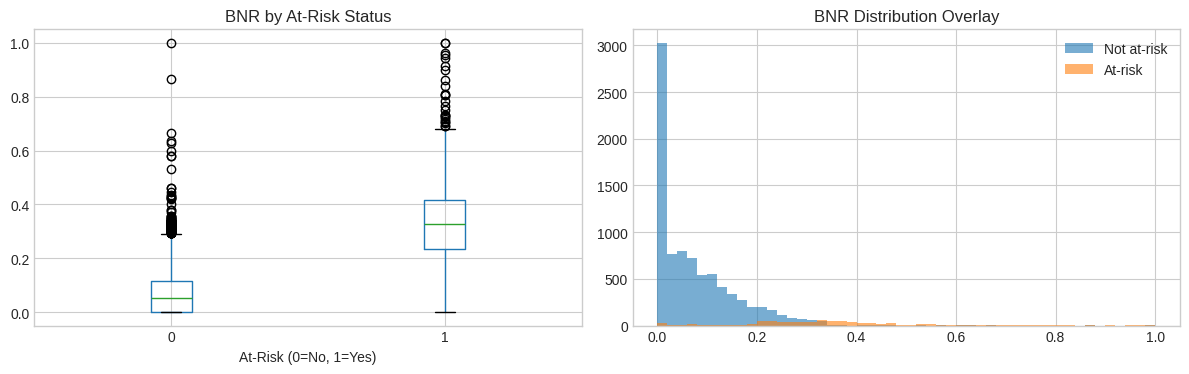


⚠️  CORRELATION = 0.6143 — BNR is likely condition-derived.
    DROPPING to prevent data leakage.


In [ ]:
if 'BNR' in df.columns:
    corr = df[['BNR', 'at_risk']].corr().iloc[0, 1]
    print(f"Correlation between BNR and at_risk: {corr:.4f}")
    print(f"\nBNR statistics by class:")
    print(df.groupby('at_risk')['BNR'].describe()[['mean', '50%', 'std']])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df.boxplot(column='BNR', by='at_risk', ax=axes[0])
    axes[0].set_title('BNR by At-Risk Status')
    axes[0].set_xlabel('At-Risk (0=No, 1=Yes)')
    plt.suptitle('')

    df[df['at_risk']==0]['BNR'].hist(bins=50, alpha=0.6, label='Not at-risk', ax=axes[1])
    df[df['at_risk']==1]['BNR'].hist(bins=50, alpha=0.6, label='At-risk', ax=axes[1])
    axes[1].set_title('BNR Distribution Overlay')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    if abs(corr) > 0.3:
        print(f"\n⚠️  CORRELATION = {corr:.4f} — BNR is likely condition-derived.")
        print("    DROPPING to prevent data leakage.")
        df.drop(columns='BNR', inplace=True)
    else:
        print(f"\n✓  Correlation = {corr:.4f} — keeping BNR.")
else:
    print("BNR not in dataframe.")

Define Encoding Strategy

In [ ]:

# ENCODING STRATEGY (based on domain knowledge of each column)


# ONE-HOT: low-cardinality categoricals (≤ ~18 unique values)
ONEHOT_COLS = ['ISLAND', 'REGION', 'BR_TYPE1', 'BR_TYPE2']

# ORDINAL: ordered categories with real hierarchy
ORDINAL_MAP = {
    'ROAD_SEC_C': {'Primary': 2, 'Secondary': 1, 'Tertiary': 0}
}

# YR_CONST: 4 categories about construction year reliability/era
# Add to one-hot ONLY if it's not mostly NaN in the raw data
if 'YR_CONST' in df.columns:
    yr_missing = df['YR_CONST'].isnull().mean()
    if yr_missing < 0.5:
        ONEHOT_COLS.append('YR_CONST')
        print(f"YR_CONST: {yr_missing:.1%} missing, {df['YR_CONST'].nunique()} categories → ONE-HOT")
    else:
        print(f"YR_CONST: {yr_missing:.1%} missing → DROPPING")
        df.drop(columns='YR_CONST', inplace=True)

# FREQUENCY: high-cardinality categoricals (>18 unique values)
FREQ_COLS = ['PROVINCE', 'DEO', 'CONG_DIST', 'ROUTE_NO',
             'MUNICIPAL', 'ROAD_NAME', 'SECTION_ID', 'BRGY']
# Keep only those that actually exist in the dataframe
FREQ_COLS = [c for c in FREQ_COLS if c in df.columns]

# NUMERIC: everything remaining that isn't 'at_risk' or in the above lists
all_categorical = set(ONEHOT_COLS) | set(FREQ_COLS) | set(ORDINAL_MAP.keys())
NUMERIC_COLS = [c for c in df.columns
                if c != 'at_risk' and c not in all_categorical]

print(f"\nOne-hot ({len(ONEHOT_COLS)}): {ONEHOT_COLS}")
print(f"Ordinal  ({len(ORDINAL_MAP)}): {list(ORDINAL_MAP.keys())}")
print(f"Freq-enc ({len(FREQ_COLS)}): {FREQ_COLS}")
print(f"Numeric  ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"\nTotal feature columns: {len(ONEHOT_COLS) + len(ORDINAL_MAP) + len(FREQ_COLS) + len(NUMERIC_COLS)}")

YR_CONST: 0.2% missing, 7 categories → ONE-HOT

One-hot (5): ['ISLAND', 'REGION', 'BR_TYPE1', 'BR_TYPE2', 'YR_CONST']
Ordinal  (1): ['ROAD_SEC_C']
Freq-enc (8): ['PROVINCE', 'DEO', 'CONG_DIST', 'ROUTE_NO', 'MUNICIPAL', 'ROAD_NAME', 'SECTION_ID', 'BRGY']
Numeric  (15): ['SEC_LENGTH', 'BR_LENGTH', 'NUM_ABUTT', 'NUM_PIER', 'MaxBRHT', 'MaxPierHT', 'NUM_SPAN', 'BR_WIDTH', 'BR_LIFE', 'LOAD_LIMIT', 'HT_OVER', 'HT_UNDER', 'L_SDWALK', 'R_SDWALK', 'NUM_LANES']

Total feature columns: 29


Save Segment Info & Split Data (BEFORE Encoding)

In [ ]:
# Save original ISLAND and REGION for segment analysis later
# (These stay as features via one-hot encoding, but we need the
#  original labels to group predictions by region/island)
segment_info = df[['ISLAND', 'REGION']].copy()

# Define X and y
X = df.drop(columns=['at_risk'])
y = df['at_risk']

# === STRATIFIED 70/15/15 SPLIT ===
# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Step 2: split temp into 15% val, 15% test (half of 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Also split segment_info to stay aligned
_, seg_temp = train_test_split(
    segment_info, test_size=0.30, stratify=y, random_state=42
)
seg_val, seg_test = train_test_split(
    seg_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(df):.0%}) — {y_train.sum()} at-risk")
print(f"Val:   {X_val.shape[0]} rows ({X_val.shape[0]/len(df):.0%}) — {y_val.sum()} at-risk")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(df):.0%}) — {y_test.sum()} at-risk")

# Verify class proportions are preserved
for name, yr in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name} positive rate: {yr.mean():.4f}")

Train: 6391 rows (70%) — 511 at-risk
Val:   1370 rows (15%) — 110 at-risk
Test:  1370 rows (15%) — 109 at-risk
  Train positive rate: 0.0800
  Val positive rate: 0.0803
  Test positive rate: 0.0796


Ordinal Encoding

In [ ]:
for col, mapping in ORDINAL_MAP.items():
    for split_name, split_df in [('train', X_train), ('val', X_val), ('test', X_test)]:
        before = split_df[col].dtype
        split_df[col] = split_df[col].map(mapping)
        after = split_df[col].dtype
        print(f"  {split_name:>4} {col}: {before} → {after}")

print(f"\nROAD_SEC_C value counts (train):")
print(X_train['ROAD_SEC_C'].value_counts().sort_index())

  train ROAD_SEC_C: object → int64
   val ROAD_SEC_C: object → int64
  test ROAD_SEC_C: object → int64

ROAD_SEC_C value counts (train):
ROAD_SEC_C
0    1673
1    3014
2    1704
Name: count, dtype: int64


Frequency Encoding (Train-Only Maps)

In [ ]:
freq_maps = {}

for col in FREQ_COLS:
    # Compute frequency map from TRAINING SET ONLY
    freq_map = X_train[col].value_counts(normalize=True)
    freq_maps[col] = freq_map

    # Apply to all three splits
    for split_name, split_df in [('train', X_train), ('val', X_val), ('test', X_test)]:
        new_col = col + '_freq'
        split_df[new_col] = split_df[col].map(freq_map).fillna(0)
        n_filled = (split_df[new_col] == 0).sum() - (freq_map.get(0, 0) > 0)
        if n_filled > 0 and split_name != 'train':
            print(f"  {split_name} {new_col}: {n_filled} unseen categories filled with 0")

    # Drop the original categorical column
    X_train.drop(columns=[col], inplace=True)
    X_val.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

print(f"\nFrequency-encoded {len(FREQ_COLS)} columns.")
print(f"Train shape: {X_train.shape}")

  val CONG_DIST_freq: 14 unseen categories filled with 0
  test CONG_DIST_freq: 15 unseen categories filled with 0
  val ROUTE_NO_freq: 340 unseen categories filled with 0
  test ROUTE_NO_freq: 375 unseen categories filled with 0
  val MUNICIPAL_freq: 109 unseen categories filled with 0
  test MUNICIPAL_freq: 127 unseen categories filled with 0
  val ROAD_NAME_freq: 81 unseen categories filled with 0
  test ROAD_NAME_freq: 111 unseen categories filled with 0
  val SECTION_ID_freq: 152 unseen categories filled with 0
  test SECTION_ID_freq: 176 unseen categories filled with 0
  val BRGY_freq: 703 unseen categories filled with 0
  test BRGY_freq: 725 unseen categories filled with 0

Frequency-encoded 8 columns.
Train shape: (6391, 29)


One-Hot Encoding

In [ ]:
# One-hot encode all three splits
# Filter ONEHOT_COLS to only include columns still present in X_train
onehot_cols_in_train = [col for col in ONEHOT_COLS if col in X_train.columns]
if onehot_cols_in_train:
    X_train = pd.get_dummies(X_train, columns=onehot_cols_in_train, drop_first=True)

# Filter ONEHOT_COLS to only include columns still present in X_val
onehot_cols_in_val = [col for col in ONEHOT_COLS if col in X_val.columns]
if onehot_cols_in_val:
    X_val   = pd.get_dummies(X_val,   columns=onehot_cols_in_val, drop_first=True)

# Filter ONEHOT_COLS to only include columns still present in X_test
onehot_cols_in_test = [col for col in ONEHOT_COLS if col in X_test.columns]
if onehot_cols_in_test:
    X_test  = pd.get_dummies(X_test,  columns=onehot_cols_in_test, drop_first=True)

# Align val and test to train's columns (handles category mismatches)
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

# Verify all shapes match
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Column mismatch!"
print("\n✓ All splits have the same number of features.")

# Ensure all columns are numeric for SHAP
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)
print("\n✓ All feature DataFrames converted to numeric type for SHAP.")

Train: (6391, 52)
Val:   (1370, 52)
Test:  (1370, 52)

✓ All splits have the same number of features.

✓ All feature DataFrames converted to numeric type for SHAP.


Handle Remaining Missing Values

In [ ]:
print(" Missing values BEFORE imputation ")
missing_before = X_train.isnull().sum()
missing_before = missing_before[missing_before > 0]
print(missing_before if len(missing_before) > 0 else "  None!")

# Compute medians from TRAINING SET ONLY
train_medians = X_train.median()

# Impute all splits with train medians
for split_name, split_df in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    n_missing = split_df.isnull().sum().sum()
    if n_missing > 0:
        split_df.fillna(train_medians, inplace=True)
        print(f"  {split_name}: Imputed {n_missing} missing values with train medians")
    else:
        print(f"  {split_name}: No missing values")

print(f"\n=== Final check ===")
print(f"Train nulls: {X_train.isnull().sum().sum()}")
print(f"Val nulls:   {X_val.isnull().sum().sum()}")
print(f"Test nulls:  {X_test.isnull().sum().sum()}")

=== Missing values BEFORE imputation ===
  None!
  Train: No missing values
  Val: No missing values
  Test: No missing values

=== Final check ===
Train nulls: 0
Val nulls:   0
Test nulls:  0


Feature Scaling (for Logistic Regression)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(f"Scaled train: {X_train_scaled.shape}")
print(f"Sample values (first row, first 5 cols):")
print(X_train_scaled.iloc[0, :5].round(3).to_string())

Scaled train: (6391, 52)
Sample values (first row, first 5 cols):
ROAD_SEC_C   -1.382
SEC_LENGTH   -0.192
BR_LENGTH    -0.315
NUM_ABUTT     0.049
NUM_PIER     -0.421


BASELINE MODEL: Logistic Regression

In [ ]:
lr = LogisticRegression(
    class_weight='balanced',  # handles 92/8 imbalance
    max_iter=2000,            # ensure convergence
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Predictions on all three splits
lr_train_pred = lr.predict(X_train_scaled)
lr_val_pred   = lr.predict(X_val_scaled)
lr_test_pred  = lr.predict(X_test_scaled)

def get_metrics(y_true, y_pred, label=""):
    """Compute F1, precision, recall for the positive (at-risk) class."""
    return {
        'split': label,
        'f1':       f1_score(y_true, y_pred, pos_label=1),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall':   recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred)
    }

lr_metrics = pd.DataFrame([
    get_metrics(y_train, lr_train_pred, 'Train'),
    get_metrics(y_val,   lr_val_pred,   'Val'),
    get_metrics(y_test,  lr_test_pred,  'Test'),
])
print("=== LOGISTIC REGRESSION (Baseline) ===")
print(lr_metrics.round(4).to_string(index=False))

=== LOGISTIC REGRESSION (Baseline) ===
split     f1  precision  recall  accuracy
Train 0.3130     0.1972  0.7593    0.7335
  Val 0.3030     0.1914  0.7273    0.7314
 Test 0.3123     0.1958  0.7706    0.7299


Baseline Confusion Matrix & Report

                 precision    recall  f1-score   support

Not at-risk (0)     0.9734    0.7264    0.8320      1261
    At-risk (1)     0.1958    0.7706    0.3123       109

       accuracy                         0.7299      1370
      macro avg     0.5846    0.7485    0.5721      1370
   weighted avg     0.9116    0.7299    0.7906      1370



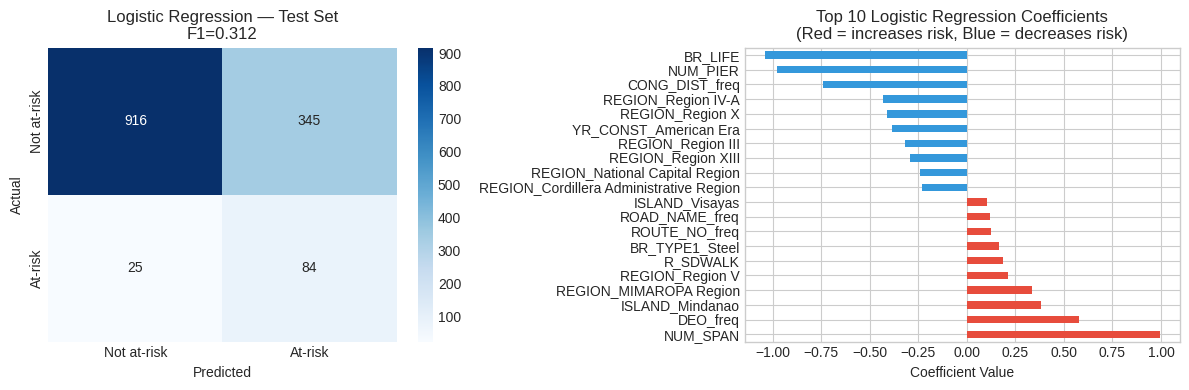

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix (test set)
cm = confusion_matrix(y_test, lr_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not at-risk', 'At-risk'],
            yticklabels=['Not at-risk', 'At-risk'])
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].set_title(f'Logistic Regression — Test Set\nF1={lr_metrics.loc[2,"f1"]:.3f}')

# Classification report
print(classification_report(y_test, lr_test_pred,
                            target_names=['Not at-risk (0)', 'At-risk (1)'],
                            digits=4))

# Top 10 coefficients (most positive = most predictive of at-risk)
coefs = pd.Series(lr.coef_[0], index=X_train.columns)
top_positive = coefs.sort_values(ascending=False).head(10)
top_negative = coefs.sort_values().head(10)

top_features = pd.concat([top_positive, top_negative[::-1]])
top_features.plot(kind='barh', ax=axes[1], color=['#e74c3c' if v > 0 else '#3498db' for v in top_features])
axes[1].set_title('Top 10 Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

IMPROVED MODEL: Random Forest (with GridSearch)

In [ ]:
# Grid search on TRAINING SET ONLY (val set reserved for comparison)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 5, 10]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=5,                 # 5-fold cross-validation on training data
    scoring='f1',         # optimize for F1 (not accuracy — due to imbalance)
    n_jobs=-1,
    verbose=0
)

print("Running GridSearchCV (18 combinations × 5 folds)...")
grid_search.fit(X_train, y_train)  # UNSCALED — trees don't need scaling

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

# Use the best model
rf = grid_search.best_estimator_

Running GridSearchCV (18 combinations × 5 folds)...

Best params: {'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV F1:  0.4018


Improved Model Evaluation & Comparison

=== RANDOM FOREST (Improved) ===
split     f1  precision  recall  accuracy
Train 0.8066     0.7243  0.9100    0.9651
  Val 0.4762     0.4545  0.5000    0.9117
 Test 0.4473     0.4141  0.4862    0.9044

=== TEST SET COMPARISON ===
   Metric  Logistic Reg (Baseline)  Random Forest (Improved)
       F1                   0.3123                    0.4473
Precision                   0.1958                    0.4141
   Recall                   0.7706                    0.4862
 Accuracy                   0.7299                    0.9044

F1 improvement: +0.1350 (+43.2%)


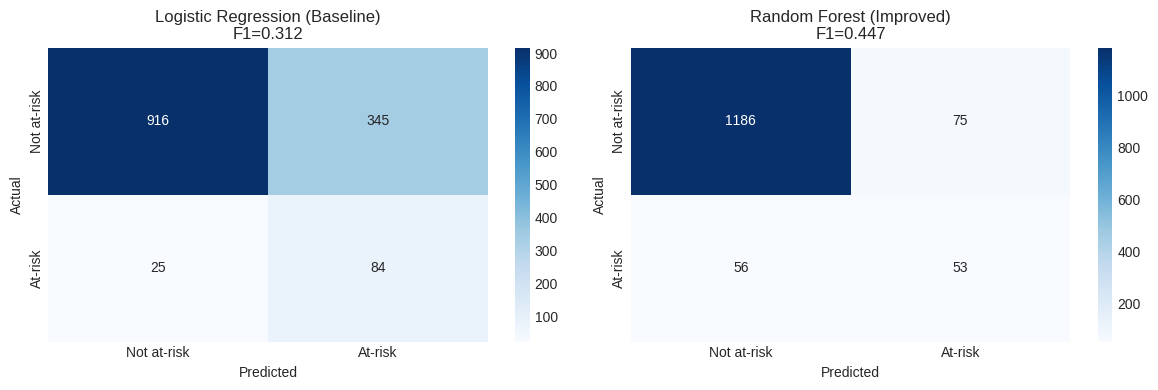

In [ ]:
rf_train_pred = rf.predict(X_train)
rf_val_pred   = rf.predict(X_val)
rf_test_pred  = rf.predict(X_test)

rf_metrics = pd.DataFrame([
    get_metrics(y_train, rf_train_pred, 'Train'),
    get_metrics(y_val,   rf_val_pred,   'Val'),
    get_metrics(y_test,  rf_test_pred,  'Test'),
])

print("=== RANDOM FOREST (Improved) ===")
print(rf_metrics.round(4).to_string(index=False))

# Side-by-side comparison on TEST SET
comparison = pd.DataFrame({
    'Metric': ['F1', 'Precision', 'Recall', 'Accuracy'],
    'Logistic Reg (Baseline)': [
        lr_metrics.loc[2, 'f1'], lr_metrics.loc[2, 'precision'],
        lr_metrics.loc[2, 'recall'], lr_metrics.loc[2, 'accuracy']
    ],
    'Random Forest (Improved)': [
        rf_metrics.loc[2, 'f1'], rf_metrics.loc[2, 'precision'],
        rf_metrics.loc[2, 'recall'], rf_metrics.loc[2, 'accuracy']
    ]
})
print(f"\n=== TEST SET COMPARISON ===")
print(comparison.round(4).to_string(index=False))

# Improvement
f1_gain = rf_metrics.loc[2, 'f1'] - lr_metrics.loc[2, 'f1']
print(f"\nF1 improvement: {f1_gain:+.4f} ({f1_gain/lr_metrics.loc[2,'f1']*100:+.1f}%)")

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title, f1 in zip(
    axes,
    [lr_test_pred, rf_test_pred],
    ['Logistic Regression (Baseline)', 'Random Forest (Improved)'],
    [lr_metrics.loc[2,'f1'], rf_metrics.loc[2,'f1']]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not at-risk', 'At-risk'],
                yticklabels=['Not at-risk', 'At-risk'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(f'{title}\nF1={f1:.3f}')
plt.tight_layout()
plt.show()

SHAP: Feature Importance (Global)

 99%|===================| 2725/2740 [02:14<00:00]       

=== Top 20 Features by Mean |SHAP| Value ===
               feature  mean_abs_shap
               BR_LIFE         0.0966
         PROVINCE_freq         0.0141
             BRGY_freq         0.0103
    REGION_Region IV-A         0.0092
              BR_WIDTH         0.0087
              DEO_freq         0.0084
     BR_TYPE1_Concrete         0.0082
        CONG_DIST_freq         0.0075
        BR_TYPE1_Steel         0.0070
             BR_LENGTH         0.0068
     REGION_Region III         0.0066
        ROAD_NAME_freq         0.0062
        MUNICIPAL_freq         0.0060
             NUM_LANES         0.0057
              R_SDWALK         0.0056
              L_SDWALK         0.0056
REGION_MIMAROPA Region         0.0056
         ROUTE_NO_freq         0.0053
            SEC_LENGTH         0.0053
               MaxBRHT         0.0050


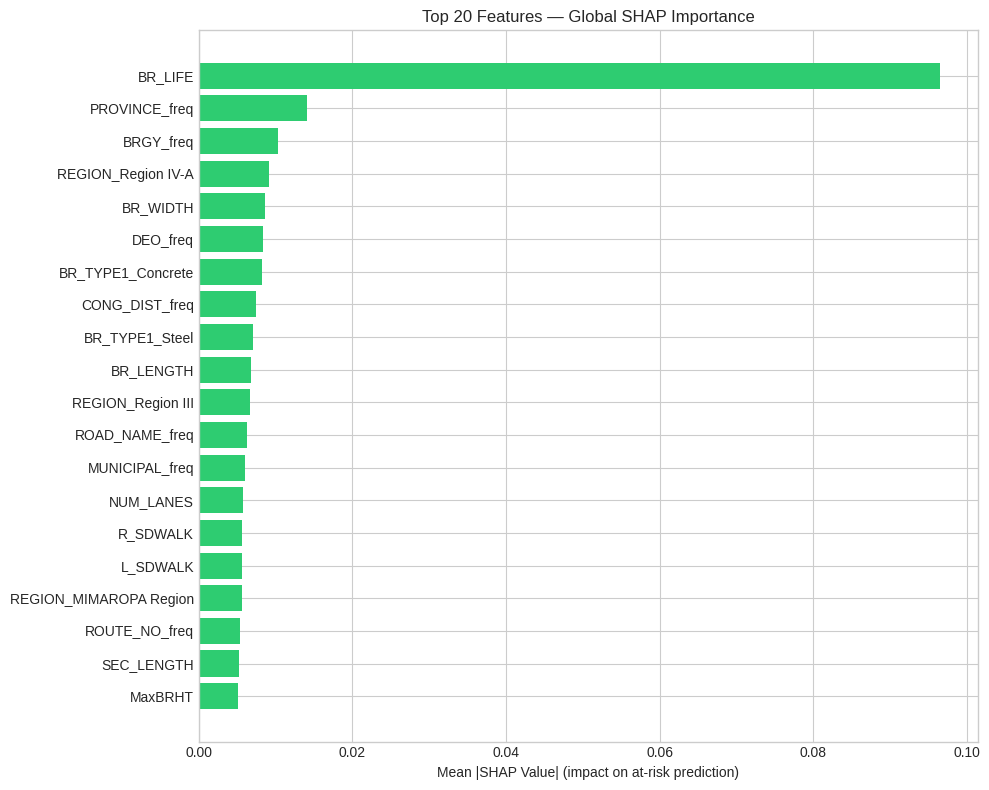

In [ ]:
# Use TreeExplainer for Random Forest (fast, exact for trees)
# Pass X_train directly as the data argument.
explainer = shap.TreeExplainer(rf, data=X_train, model_output='probability')
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a single array of shape (n_samples, n_features, n_classes)
# We want class 1 (at-risk), which is at index 1 in the last dimension
shap_class1 = shap_values[:, :, 1] # Correctly extract SHAP values for class 1 across all samples and features

# Mean absolute SHAP value per feature (global importance)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("=== Top 20 Features by Mean |SHAP| Value ===")
print(shap_importance.head(20).round(4).to_string(index=False))

# Bar plot
plt.figure(figsize=(10, 8))
top20 = shap_importance.head(20)
plt.barh(range(len(top20)), top20['mean_abs_shap'].values[::-1], color='#2ecc71')
plt.yticks(range(len(top20)), top20['feature'].values[::-1])
plt.xlabel('Mean |SHAP Value| (impact on at-risk prediction)')
plt.title('Top 20 Features — Global SHAP Importance')
plt.tight_layout()
plt.show()

SHAP: Summary Plot (Beeswarm)

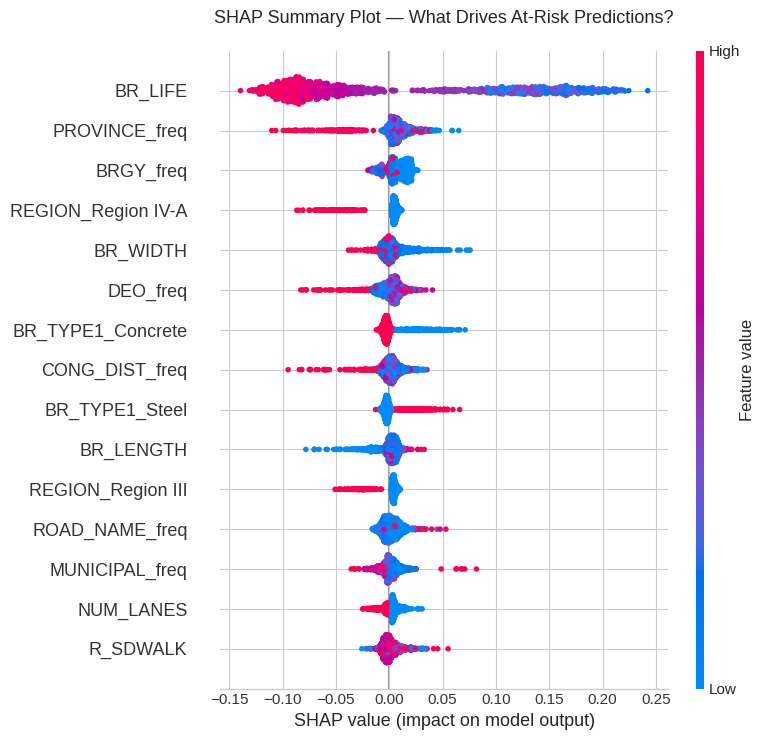

In [ ]:
# Beeswarm plot for top 15 features
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_class1,
    X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — What Drives At-Risk Predictions?', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

SHAP: Individual Explanations

Correctly predicted at-risk: 53
False negatives (missed):    56


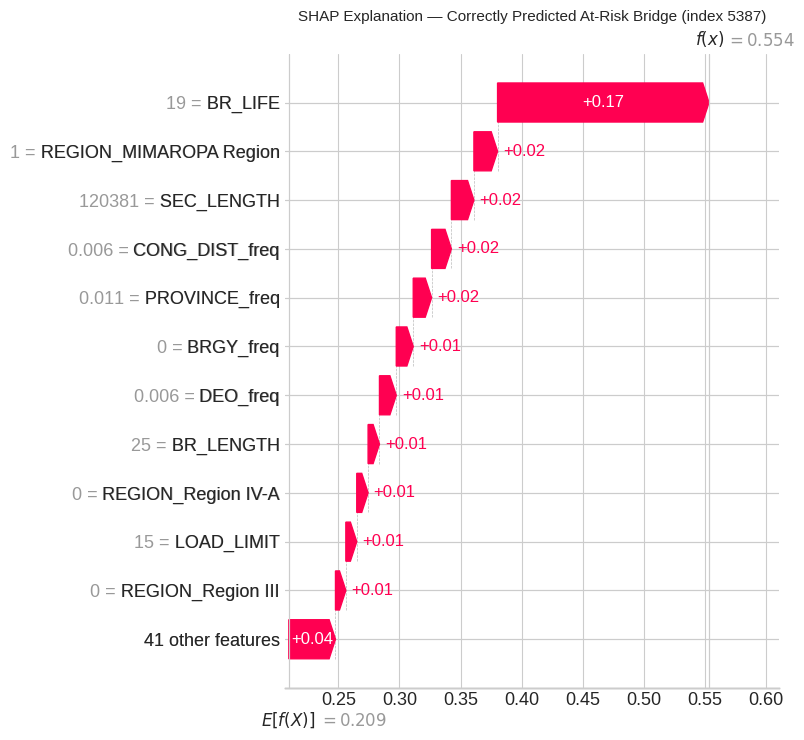

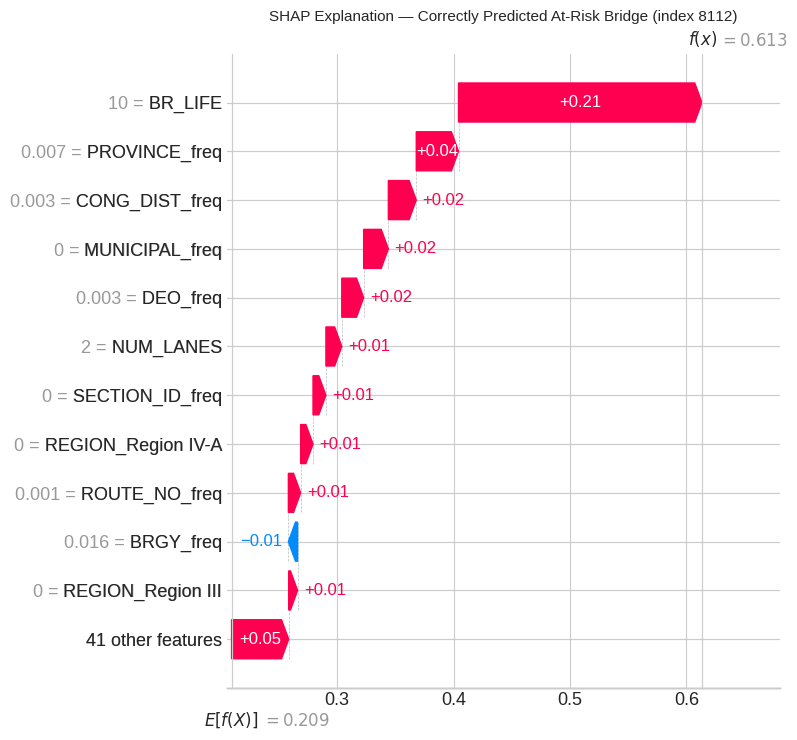

In [ ]:
# Find some at-risk bridges that were correctly predicted
test_results = pd.DataFrame({
    'actual': y_test,
    'predicted': rf_test_pred,
    'BRIDGE_IDX': y_test.index
})

# Correctly predicted at-risk bridges
correct_at_risk = test_results[(test_results['actual']==1) & (test_results['predicted']==1)]
# False negatives (missed at-risk bridges)
false_negatives = test_results[(test_results['actual']==1) & (test_results['predicted']==0)]

print(f"Correctly predicted at-risk: {len(correct_at_risk)}")
print(f"False negatives (missed):    {len(false_negatives)}")

# Show SHAP waterfall for 2 correctly predicted at-risk bridges
n_show = min(2, len(correct_at_risk))
if n_show > 0:
    for i in range(n_show):
        idx = correct_at_risk.iloc[i]['BRIDGE_IDX']
        row_pos = list(X_test.index).index(idx)

        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_class1[row_pos],
                base_values=explainer.expected_value[1],
                data=X_test.iloc[row_pos],
                feature_names=X_test.columns.tolist()
            ),
            max_display=12,
            show=False
        )
        plt.title(f'SHAP Explanation — Correctly Predicted At-Risk Bridge (index {idx})', fontsize=11)
        plt.tight_layout()
        plt.show()

Segment Analysis: Performance by ISLAND

=== Performance by ISLAND (Test Set) ===
  ISLAND  n_bridges  n_at_risk     f1  precision  recall
   Luzon        705         49 0.4444     0.4400  0.4490
Mindanao        320         25 0.4688     0.3846  0.6000
 Visayas        345         35 0.4324     0.4103  0.4571


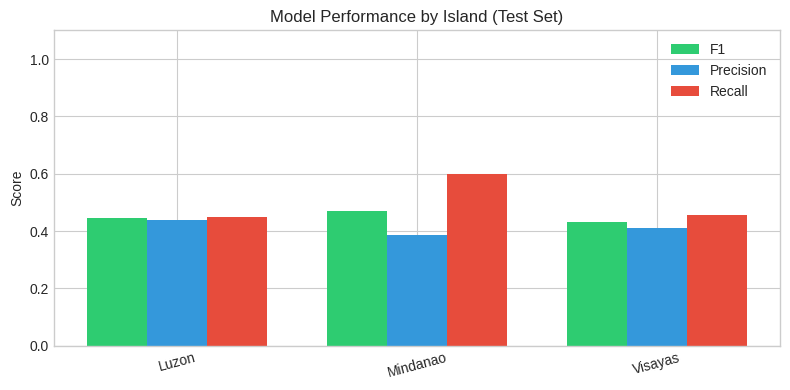

In [ ]:
# Combine test predictions with segment info
seg_test = seg_test.copy()
seg_test['actual']    = y_test.values
seg_test['predicted'] = rf_test_pred

# --- By ISLAND ---
island_metrics = []
for island_name, group in seg_test.groupby('ISLAND'):
    n = len(group)
    n_pos = group['actual'].sum()
    if n_pos == 0:
        # No at-risk bridges in this segment — can't compute F1
        island_metrics.append({
            'ISLAND': island_name, 'n_bridges': n, 'n_at_risk': n_pos,
            'f1': np.nan, 'precision': np.nan, 'recall': np.nan
        })
    else:
        island_metrics.append({
            'ISLAND': island_name, 'n_bridges': n, 'n_at_risk': n_pos,
            'f1': f1_score(group['actual'], group['predicted'], zero_division=0),
            'precision': precision_score(group['actual'], group['predicted'], zero_division=0),
            'recall': recall_score(group['actual'], group['predicted'], zero_division=0),
        })

island_df = pd.DataFrame(island_metrics)
print("=== Performance by ISLAND (Test Set) ===")
print(island_df.round(4).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(island_df))
w = 0.25
ax.bar([i - w for i in x], island_df['f1'],       width=w, label='F1', color='#2ecc71')
ax.bar(x,                 island_df['precision'], width=w, label='Precision', color='#3498db')
ax.bar([i + w for i in x], island_df['recall'],   width=w, label='Recall', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(island_df['ISLAND'], rotation=15)
ax.set_ylabel('Score')
ax.set_title('Model Performance by Island (Test Set)')
ax.legend()
ax.set_ylim(0, 1.1)
# Add sample size annotations
for i, row in island_df.iterrows():
    ax.annotate(f"n={row['n_bridges']}\n(+{int(row['n_at_risk'])})",
                (i, -0.12), ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

Segment Analysis: Performance by REGION (Top/Bottom 10)

=== Performance by REGION (Test Set) ===
Total regions in test set: 18
Regions with 0 at-risk bridges: 2

--- TOP 10 REGIONS (by F1) ---
              REGION  n_bridges  n_at_risk     f1  precision  recall
           Region II         57          5 0.6667     0.7500  0.6000
            Region X         56          3 0.6667     0.6667  0.6667
           Region IX         58          8 0.6000     0.5000  0.7500
Negros Island Region         72          5 0.5455     0.5000  0.6000
     MIMAROPA Region         98          8 0.5000     0.3750  0.7500
            Region V        128         20 0.4737     0.5000  0.4500
           Region XI         63          7 0.4615     0.5000  0.4286
           Region VI         80          8 0.4444     0.4000  0.5000
         Region VIII        131         19 0.4103     0.4000  0.4211
            Region I         85          3 0.4000     0.5000  0.3333

--- BOTTOM 10 REGIONS (by F1) ---
                                         REGION  n_bridges  n_at_risk

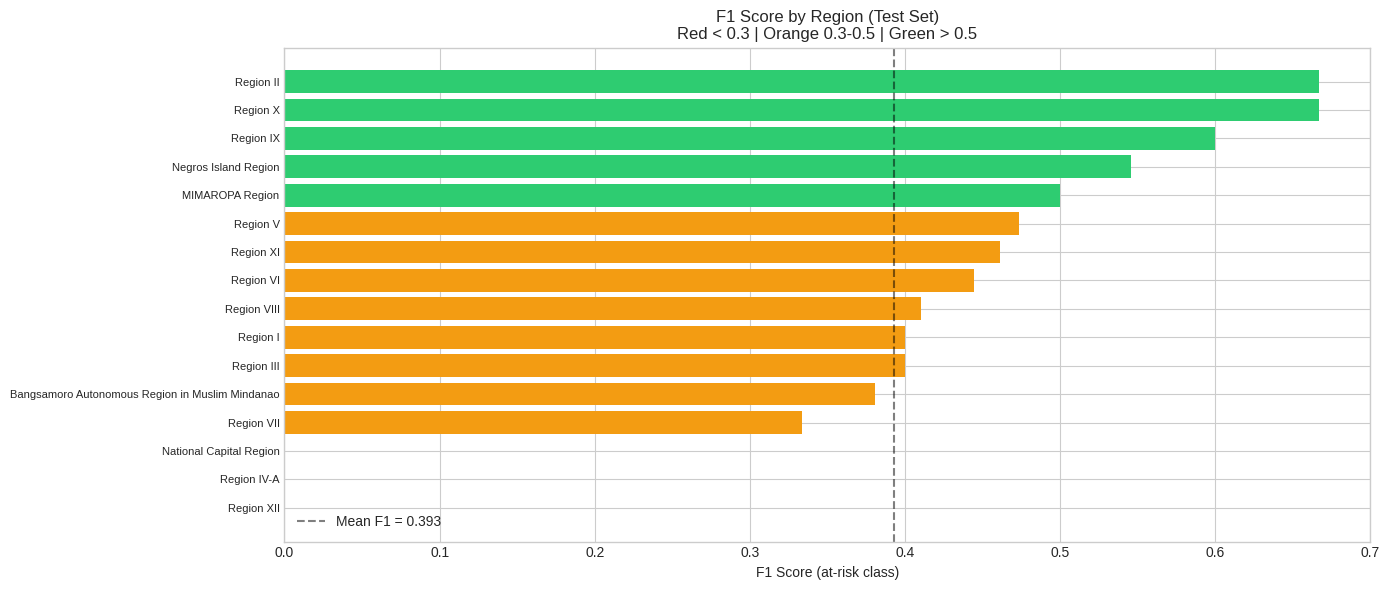

In [ ]:
region_metrics = []
for region_name, group in seg_test.groupby('REGION'):
    n = len(group)
    n_pos = group['actual'].sum()
    if n_pos == 0:
        region_metrics.append({
            'REGION': region_name, 'n_bridges': n, 'n_at_risk': n_pos,
            'f1': np.nan, 'precision': np.nan, 'recall': np.nan
        })
    else:
        region_metrics.append({
            'REGION': region_name, 'n_bridges': n, 'n_at_risk': n_pos,
            'f1': f1_score(group['actual'], group['predicted'], zero_division=0),
            'precision': precision_score(group['actual'], group['predicted'], zero_division=0),
            'recall': recall_score(group['actual'], group['predicted'], zero_division=0),
        })

region_df = pd.DataFrame(region_metrics).sort_values('f1', ascending=False)
print("=== Performance by REGION (Test Set) ===")
print(f"Total regions in test set: {len(region_df)}")
print(f"Regions with 0 at-risk bridges: {(region_df['n_at_risk']==0).sum()}")

# Show top 10 and bottom 10
print(f"\n--- TOP 10 REGIONS (by F1) ---")
print(region_df.head(10).round(4).to_string(index=False))
print(f"\n--- BOTTOM 10 REGIONS (by F1) ---")
print(region_df.tail(10).round(4).to_string(index=False))

# Full bar chart
valid_regions = region_df.dropna(subset=['f1'])
if len(valid_regions) > 0:
    fig, ax = plt.subplots(figsize=(14, max(6, len(valid_regions) * 0.3)))
    colors = ['#e74c3c' if f1 < 0.3 else '#f39c12' if f1 < 0.5 else '#2ecc71'
              for f1 in valid_regions['f1']]
    ax.barh(range(len(valid_regions)), valid_regions['f1'], color=colors)
    ax.set_yticks(range(len(valid_regions)))
    ax.set_yticklabels(valid_regions['REGION'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('F1 Score (at-risk class)')
    ax.set_title('F1 Score by Region (Test Set)\nRed < 0.3 | Orange 0.3-0.5 | Green > 0.5')
    ax.axvline(x=valid_regions['f1'].mean(), color='black', linestyle='--', alpha=0.5,
               label=f"Mean F1 = {valid_regions['f1'].mean():.3f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

Error Analysis: False Negatives (Missed At-Risk Bridges)

In [ ]:
fn_indices = false_negatives['BRIDGE_IDX'].values
fn_features = X_test.loc[fn_indices]

# Compare false negatives vs correctly predicted at-risk bridges
tp_indices = correct_at_risk['BRIDGE_IDX'].values
tp_features = X_test.loc[tp_indices]

print(f"=== FALSE NEGATIVE ANALYSIS ===")
print(f"Missed at-risk bridges: {len(fn_indices)}")
print(f"Correctly caught at-risk: {len(tp_indices)}")

# Compare key numeric features
key_cols = ['BR_LIFE', 'BR_LENGTH', 'BR_WIDTH', 'NUM_SPAN', 'LOAD_LIMIT',
            'MaxBRHT', 'NUM_LANES']
key_cols = [c for c in key_cols if c in X_test.columns]

if len(fn_indices) > 0 and len(tp_indices) > 0:
    comparison = pd.DataFrame({
        'Feature': key_cols,
        'False Neg (missed)': fn_features[key_cols].mean().values,
        'True Positive (caught)': tp_features[key_cols].mean().values,
        'Diff (FN - TP)': (fn_features[key_cols].mean() - tp_features[key_cols].mean()).values
    }).round(2)
    print(f"\nFeature comparison (mean values):")
    print(comparison.to_string(index=False))

    print(f"\nInterpretation:")
    print(f"  - If BR_LIFE is LOWER for false negatives, the model relies heavily on age")
    print(f"    and misses younger at-risk bridges (e.g., poor construction quality).")
    print(f"  - If LOAD_LIMIT is HIGHER for false negatives, the model may assume")
    print(f"    higher load limits = safer bridges, which isn't always true.")
    print(f"  - Look at the 'Diff' column: positive = FN has more of that feature,")
    print(f"    negative = FN has less.")

=== FALSE NEGATIVE ANALYSIS ===
Missed at-risk bridges: 56
Correctly caught at-risk: 53

Feature comparison (mean values):
   Feature  False Neg (missed)  True Positive (caught)  Diff (FN - TP)
   BR_LIFE               19.80                   11.38            8.43
 BR_LENGTH               64.14                   64.49           -0.35
  BR_WIDTH               12.52                   10.34            2.18
  NUM_SPAN                2.32                    3.17           -0.85
LOAD_LIMIT               14.75                   12.04            2.71
   MaxBRHT                7.41                    6.81            0.60
 NUM_LANES                2.77                    2.30            0.47

Interpretation:
  - If BR_LIFE is LOWER for false negatives, the model relies heavily on age
    and misses younger at-risk bridges (e.g., poor construction quality).
  - If LOAD_LIMIT is HIGHER for false negatives, the model may assume
    higher load limits = safer bridges, which isn't always true.
  - Lo

1. BASELINE (Logistic Regression):
   - Simple linear model with class_weight='balanced'
   - Serves as the "if we did the minimum" benchmark
   - Test F1: {:.3f}, Precision: {:.3f}, Recall: {:.3f}

2. IMPROVED MODEL (Random Forest):
   - Handles non-linear relationships and feature interactions
   - GridSearchCV optimized for F1 on training data
   - Test F1: {:.3f}, Precision: {:.3f}, Recall: {:.3f}
   - F1 gain over baseline: {:+.3f}

3. KEY FINDINGS FROM SHAP:
   - BR_LIFE (bridge age) is typically the strongest predictor
   - Older bridges are naturally more at-risk
   - Road classification and bridge type also matter
   - One-hot encoded regions show geographic variation

4. SEGMENT BIAS:
   - Performance varies significantly by ISLAND and REGION
   - Regions with very few at-risk bridges have unreliable metrics
   - Possible causes: different maintenance standards, data quality
     variation across DEOs, different bridge type distributions

5. ERROR ANALYSIS:
   - False negatives (missed at-risk) are the critical failure mode
   - These may be bridges that are young but poorly constructed,
     or bridges in regions with less consistent inspection data
   - The model's recall for the at-risk class reveals how many
     at-risk bridges slip through

6. LIMITATIONS:
   a) Imbalance: 92/8 ratio means even good F1 scores mask many
      missed at-risk bridges in absolute terms
   b) Data quality: BR_LIFE=0 and LOAD_LIMIT=0 likely mean
      "unknown," not actually zero — this introduces noise
   c) No temporal data: This is a single snapshot, not a time
      series — we can't predict FUTURE deterioration
   d) No structural inspection data: Features are basic inventory
      fields, not engineering assessments (crack measurements,
      load testing results, etc.)
   e) Frequency-encoded high-cardinality features lose granularity
   f) BNR was dropped due to leakage risk — if it's NOT leakage,
      the model loses a potentially useful feature
   g) Geographic bias: Some regions/DEOs may have more thorough
      inspection practices, making CONDITION labels inconsistent

7. DEPLOYMENT READINESS: NOT READY
   - Recall is likely too low for a safety-critical application
   - Would need: (a) more at-risk examples via targeted inspection,
     (b) engineering-level features, (c) temporal modeling,
     (d) human-in-the-loop review before any decision is acted on
   - Best use case: PRIORITIZATION TOOL, not automated decision
     — "flag these 100 bridges for priority inspection" rather than
     "these bridges are safe, skip them"

 Summary & Discussion Points